<a href="https://colab.research.google.com/github/ChocoMoose24/animal_identifier/blob/main/working_animal_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
# You have to run it everytime to connect to Google drive data
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
!ls /content/drive/MyDrive/WVA_animal_classification/animal-image-dataset-90-different-animals/animals/

animals


In [30]:
# import stuff
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras import layers

import matplotlib.pyplot as plt

import pandas as pd


In [16]:
#import kagglehub #replace this with code to mount your google drive to colab

#Download latest version
#path = kagglehub.dataset_download("iamsouravbanerjee/animal-image-dataset-90-different-animals")

#path = "/content/drive/MyDrive/WVA_animal_classification/"
#print("Path to dataset files:", path)

In [31]:
!ls /content/drive/MyDrive/Anya_WVA_training/
%cd /content/drive/MyDrive/Anya_WVA_training/


checkpoints  tfjs_model
/content/drive/MyDrive/Anya_WVA_training


In [32]:
training_path = "/content/drive/MyDrive/WVA_animal_classification/animal-image-dataset-90-different-animals/animals/animals"

In [33]:
train_ds=keras.utils.image_dataset_from_directory(
    training_path,
    labels="inferred",
    label_mode = "int",
    image_size = (224,224),
    validation_split = 0.2,
    subset="training",
    batch_size = 32,
    shuffle=True,
    seed=2026
)
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

val_ds=keras.utils.image_dataset_from_directory(
    training_path,
    labels="inferred",
    label_mode = "int",
    image_size = (224,224),
    validation_split=0.2,
    subset="validation",
    batch_size = 32,
    shuffle=True,
    seed=2026
)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

Found 5400 files belonging to 90 classes.
Using 4320 files for training.
Found 5400 files belonging to 90 classes.
Using 1080 files for validation.


In [34]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224, 3),
    alpha=1.0,
    include_top=False,
    weights='imagenet',
    input_tensor=None,
    pooling='avg',
    #classes=1000,
    #classifier_activation='softmax'
)

base_model.trainable = False

In [35]:
model = keras.Sequential([
    layers.Input(shape=(224,224, 3)),

    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),

    layers.RandomBrightness(factor=0.2),

    layers.Rescaling(scale=1/127.5, offset=-1),
    base_model,

    layers.Dropout(0.4),
    layers.Dense(90, activation="softmax")
])

In [36]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [23]:
checkpoint_path = "./checkpoints/cp-{epoch:02d}.weights.h5"
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,
    verbose=1
)

add_epocs = 0
num_epocs = 40
csv_logger = tf.keras.callbacks.CSVLogger('./checkpoints/training_log.csv', append=True)

history = model.fit(train_ds, validation_data = val_ds, epochs=num_epocs, callbacks=[cp_callback, csv_logger]) #train it ten 40 epochs


Epoch 1/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1733 - loss: 4.0171
Epoch 1: saving model to ./checkpoints/cp-01.weights.h5

Epoch 1: finished saving model to ./checkpoints/cp-01.weights.h5
135/135 ━━━━━━━━━━━━━━━━━━━━ 375s 3s/step - accuracy: 0.3370 - loss: 3.0164 - val_accuracy: 0.7204 - val_loss: 1.2920
Epoch 2/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6566 - loss: 1.4238
Epoch 2: saving model to ./checkpoints/cp-02.weights.h5

Epoch 2: finished saving model to ./checkpoints/cp-02.weights.h5
135/135 ━━━━━━━━━━━━━━━━━━━━ 344s 3s/step - accuracy: 0.6694 - loss: 1.3461 - val_accuracy: 0.7796 - val_loss: 0.8661
Epoch 3/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7212 - loss: 1.0445
Epoch 3: saving model to ./checkpoints/cp-03.weights.h5

Epoch 3: finished saving model to ./checkpoints/cp-03.weights.h5
135/135 ━━━━━━━━━━━━━━━━━━━━ 355s 3s/step - accuracy: 0.7345 - loss: 0.9994 - val_accuracy: 0.8120 - val_loss: 0.7245
Epoch 4/40
135/135 ━━━━━━

In [24]:
model.save('./checkpoints/cp-40.weights.keras')

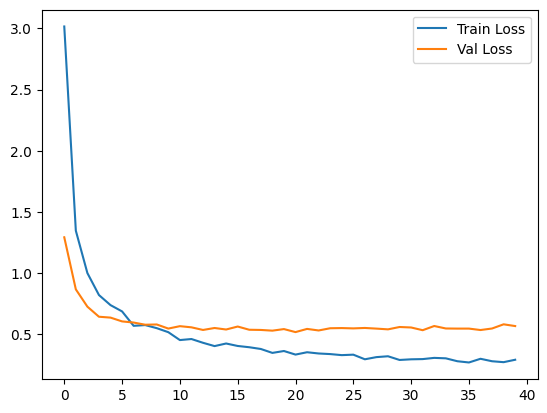

In [25]:
df = pd.read_csv('./checkpoints/training_log.csv')
plt.plot(df['epoch'], df['loss'], label='Train Loss')
plt.plot(df['epoch'], df['val_loss'], label='Val Loss')
plt.legend()
plt.show()

Epoch 1/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8829 - loss: 0.3638
Epoch 1: saving model to ./checkpoints/cp-01.weights.h5

Epoch 1: finished saving model to ./checkpoints/cp-01.weights.h5
135/135 ━━━━━━━━━━━━━━━━━━━━ 351s 3s/step - accuracy: 0.8866 - loss: 0.3600 - val_accuracy: 0.8565 - val_loss: 0.5128
Epoch 2/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8914 - loss: 0.3556
Epoch 2: saving model to ./checkpoints/cp-02.weights.h5

Epoch 2: finished saving model to ./checkpoints/cp-02.weights.h5
135/135 ━━━━━━━━━━━━━━━━━━━━ 362s 3s/step - accuracy: 0.8947 - loss: 0.3381 - val_accuracy: 0.8537 - val_loss: 0.5266
Epoch 3/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8968 - loss: 0.3389
Epoch 3: saving model to ./checkpoints/cp-03.weights.h5

Epoch 3: finished saving model to ./checkpoints/cp-03.weights.h5
135/135 ━━━━━━━━━━━━━━━━━━━━ 354s 3s/step - accuracy: 0.8961 - loss: 0.3473 - val_accuracy: 0.8509 - val_loss: 0.5281
Epoch 4/20
135/135 ━━━━━━

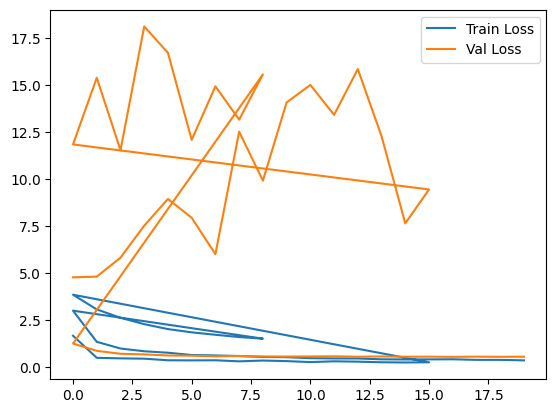

In [ ]:

# Train more epocs if needed
model.load_weights('./checkpoints/cp-40.weights.h5')
# 2. Extract exactly 1 single batch from your dataset to initialize the optimizer
#RUN THIS TO START RESTARTING
images_batch, labels_batch = next(iter(train_ds))
model.train_on_batch(images_batch[:1], labels_batch[:1])

checkpoint_path = "./checkpoints/cp-{epoch:02d}.weights.h5"
model.load_weights('./checkpoints/cp-20.weights.h5')
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,
    verbose=1
)

add_epocs = 20
initial_epoch=num_epocs
csv_logger = tf.keras.callbacks.CSVLogger('./checkpoints/training_log.csv', append=True)

history = model.fit(train_ds, validation_data = val_ds, epochs=initial_epoch+add_epocs,
                    initial_epoch=initial_epoch, callbacks=[cp_callback, csv_logger]) #train it ten 20 epochs



In [ ]:
#plotting training and valudation loss
df = pd.read_csv('./checkpoints/training_log.csv')
plt.plot(df['epoch'], df['loss'], label='Train Loss')
plt.plot(df['epoch'], df['val_loss'], label='Val Loss')
plt.legend()
plt.show()

In [27]:
fine_tune_model = keras.models.load_model('./checkpoints/cp-40.weights.keras')
#model.load_weights('./checkpoints/cp-40.weights.h5')
#model.load_weights('./checkpoints/cp-finetune-90.weights.h5')

# --- Step 2: Unfreeze the base model layers ---
base_model.trainable = True

# Fine-tune from this layer onwards (MobileNetV2 has 154 layers total)
# Freezing the first 100 layers preserves low-level features (edges, textures) *LAYER 18 IS WHERE THE FIRST 2 STAGES END*
fine_tune_at = 20
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# --- Step 3: MUST RECOMPILE AFTER CHANGING TRAINABILITY ---
# Use a very low learning rate for fine-tuning
fine_tune_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy', # Change to sparse_categorical_crossentropy if labels are integers
    metrics=['accuracy']
)

# --- Step 4: Run a single step to initialize variables (Optional but safe) ---
images_batch, labels_batch = next(iter(train_ds))
fine_tune_model.train_on_batch(images_batch[:1], labels_batch[:1])

checkpoint_path = "./checkpoints/cp-finetune-{epoch:02d}.weights.keras"

cp_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=False,
    verbose=1
)

# Appending to your existing CSV log is fine
csv_logger = tf.keras.callbacks.CSVLogger('./checkpoints/training_log.csv', append=True)

# --- Step 6: Start Fine-Tuning ---
# Notice we pass initial_epoch=20 so the log correctly reflects epochs 21-40
history = fine_tune_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,               # Total epochs target
    initial_epoch=40,        # Starts training at epoch 40
    callbacks=[cp_callback, csv_logger]
)

Epoch 41/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9181 - loss: 0.2469
Epoch 41: saving model to ./checkpoints/cp-finetune-41.weights.keras

Epoch 41: finished saving model to ./checkpoints/cp-finetune-41.weights.keras
135/135 ━━━━━━━━━━━━━━━━━━━━ 330s 2s/step - accuracy: 0.9206 - loss: 0.2509 - val_accuracy: 0.8472 - val_loss: 0.5584
Epoch 42/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9189 - loss: 0.2530
Epoch 42: saving model to ./checkpoints/cp-finetune-42.weights.keras

Epoch 42: finished saving model to ./checkpoints/cp-finetune-42.weights.keras
135/135 ━━━━━━━━━━━━━━━━━━━━ 378s 2s/step - accuracy: 0.9197 - loss: 0.2497 - val_accuracy: 0.8500 - val_loss: 0.5514
Epoch 43/50
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9185 - loss: 0.2461
Epoch 43: saving model to ./checkpoints/cp-finetune-43.weights.keras

Epoch 43: finished saving model to ./checkpoints/cp-finetune-43.weights.keras
135/135 ━━━━━━━━━━━━━━━━━━━━ 346s 3s/step - accuracy: 0.9187 -

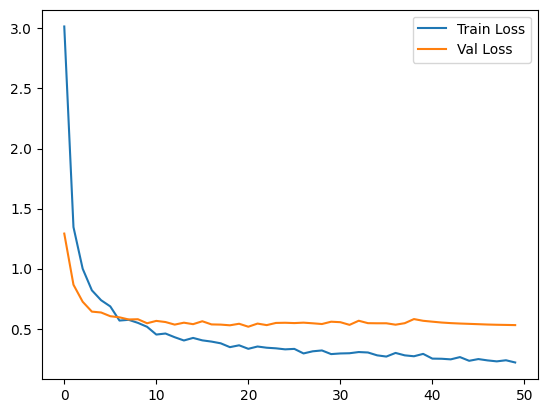

In [37]:
#plotting training and valudation loss
df = pd.read_csv('./checkpoints/training_log.csv')
plt.plot(df['epoch'], df['loss'], label='Train Loss')
plt.plot(df['epoch'], df['val_loss'], label='Val Loss')
plt.legend()
plt.show()

In [43]:
fine_tune_model.save('checkpoints/animal_detect_final.keras')

In [38]:
fine_tune_model = keras.models.load_model('./checkpoints/cp-finetune-50.weights.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step

--- Top 3 Predictions ---
1. possum (Index: 66) | Probability: 0.8977
2. wolf (Index: 86) | Probability: 0.0757
3. sheep (Index: 75) | Probability: 0.0078
Predicted class index: 66
possum
Probability of predicted animal: 0.8977283239364624


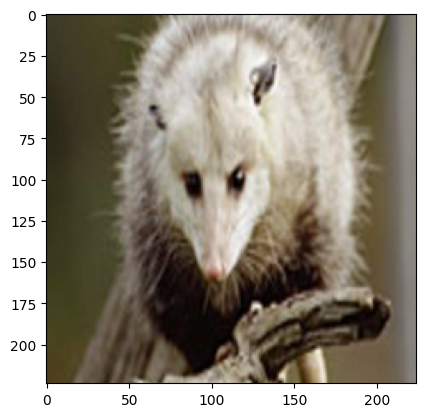

In [40]:

for images, labels in val_ds.take(1):

    first_image = images[9].numpy().astype("uint8")
    first_label = labels[9].numpy()

    img_for_prediction = np.expand_dims(first_image, axis=0)

    plt.imshow(first_image)

    with open('/content/drive/MyDrive/WVA_animal_classification/animal-image-dataset-90-different-animals/name of the animals.txt', 'r') as file:
    # Read the full text string and split it by whitespace into a list
       class_names = file.read().split()

    predictions = fine_tune_model.predict(img_for_prediction)

    probabilities = predictions[0]

    predicted_class_index = np.argmax(probabilities)

    # Get the indices that sort the probabilities from smallest to largest
    sorted_indices = np.argsort(probabilities)

    # Slice the last 3 elements and reverse them to go from highest to lowest probability
    top_3_indices = sorted_indices[-3:][::-1]

    # Print the top 3 predictions
    print("\n--- Top 3 Predictions ---")
    for i, class_idx in enumerate(top_3_indices, start=1):
        name = class_names[class_idx]
        probability = probabilities[class_idx]
        print(f"{i}. {name} (Index: {class_idx}) | Probability: {probability:.4f}")

    #print(f"prediction probabilities: {predictions[0]}")
    print(f"Predicted class index: {predicted_class_index}")
    print(class_names[predicted_class_index])
    print(f"Probability of predicted animal: {predictions[0][predicted_class_index]:}")

In [49]:
import tensorflowjs as tfjs
import tensorflow as tf

inference_model = tf.keras.Sequential([
    # Define the base input layer
tf.keras.layers.Input(shape=(224, 224, 3), name="input_layer"),

    # Extract your explicit Rescaling layer from the original model
fine_tune_model.get_layer('rescaling_1'),

    # Include your trained MobileNetV2 base
base_model,

    # Extract the final classification dense layer
fine_tune_model.layers[-1]
])

# 2. Convert this clean inference model object directly in memory
tfjs.converters.save_keras_model(inference_model, './tfjs_model')

print("Success! Check your file explorer on the left for the 'tfjs_model' folder.")

failed to lookup keras version from the file,
    this is likely a weight only file
Success! Check your file explorer on the left for the 'tfjs_model' folder.
